# ETF 动量回测（2024年10月起）

- 仅回测 **2024年10月** 至今数据
- 三组 Top5：①总收益 Top5（多样性合并） ②最大回撤≤25% 的 Top5  ③近期收益加权 Top5
- 与沪深300走势对比；各维度参数收益均值对比

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
import warnings
import matplotlib.pyplot as plt
import matplotlib
import time
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

from momentum_backtest_tool import (
    load_panel,
    rolling_linreg,
    precompute_linreg,
    backtest_momentum,
    compute_metrics,
    nav_key_from_row,
    find_nav,
    top5_diverse,
    recency_weighted_return,
    SLIPPAGE,
    COMMISSION,
)

DB_DIR = Path('db')

## 1. 加载数据（2024年10月起）

In [2]:
panel_full, panel_open_full = load_panel(DB_DIR)
# 仅保留 2024-10-01 及之后
start_date = pd.Timestamp('2024-10-01')
panel = panel_full.loc[panel_full.index >= start_date].copy()
panel_open = panel_open_full.loc[panel_open_full.index >= start_date].copy()
# 对齐：只保留 panel 中有的日期
panel_open = panel_open.reindex(panel.index).ffill()
print(f'加载 {panel.shape[1]} 只 ETF，{len(panel)} 个交易日')
print(f'日期范围: {panel.index[0].strftime("%Y-%m-%d")} ~ {panel.index[-1].strftime("%Y-%m-%d")}')

加载 177 只 ETF，348 个交易日
日期范围: 2024-10-08 ~ 2026-03-13


## 2. 参数网格与预计算

In [20]:
N_LIST = [3, 5, 10, 20, 30]
R2_LIST = [0.3, 0.5, 0.6, 0.7, 0.8]
REBAL_LIST = [5, 10, 20, 40]
TOP_K_LIST = [1, 3, 5]
TP_LIST = [None]
SL_DD_LIST = [0.2, 0.3, None]

param_grid_core = list(product(N_LIST, R2_LIST, REBAL_LIST, TOP_K_LIST))
param_grid_tp_sl = list(product(TP_LIST, SL_DD_LIST))
# 全量参数：(n, r2, rebal, top_k, tp, sl)
full_grid = [(n, r2, rbl, k, tp, sl) for (n, r2, rbl, k) in param_grid_core for (tp, sl) in param_grid_tp_sl]
print(f'核心参数组合数: {len(param_grid_core)}')
print(f'TP/SL 组合: {len(TP_LIST)}×{len(SL_DD_LIST)} = {len(param_grid_tp_sl)}')
print(f'全量组合数: {len(full_grid)}')

log_close = np.log(panel.replace(0, np.nan))
daily_ret = panel.pct_change()
linreg_cache = precompute_linreg(log_close, N_LIST, cache={}, verbose=True)

核心参数组合数: 300
TP/SL 组合: 1×3 = 3
全量组合数: 900
  预计算 rolling_linreg(n=3) 完成
  预计算 rolling_linreg(n=5) 完成
  预计算 rolling_linreg(n=10) 完成
  预计算 rolling_linreg(n=20) 完成
  预计算 rolling_linreg(n=30) 完成


## 3. 批量回测

In [21]:
def run_one(params):
    n, r2_thresh, rebal, top_k, take_profit, max_dd_stop = params
    slope, r2 = linreg_cache[n]
    nav = backtest_momentum(
        slope, r2, daily_ret, panel, panel_open,
        n=n, r2_threshold=r2_thresh, rebal_period=rebal, top_k=top_k,
        take_profit=take_profit, max_dd_stop=max_dd_stop,
    )
    tp_s = 'inf' if take_profit is None else str(take_profit)
    sl_s = 'inf' if max_dd_stop is None else str(max_dd_stop)
    label = f'n={n}_R2={r2_thresh}_rebal={rebal}_topk={top_k}_tp={tp_s}_sl={sl_s}'
    metrics = compute_metrics(nav, year_col_prefix='', include_last_3y=True)
    out = {
        'n': n, 'R2_threshold': r2_thresh, 'rebal_period': rebal, 'top_k': top_k,
        'take_profit': take_profit, 'max_dd_stop': max_dd_stop,
    }
    out.update(metrics)
    return label, nav, out

results = []
nav_cache = {}
t0 = time.time()
for prm in full_grid:
    label, nav, out = run_one(prm)
    nav_cache[label] = nav
    results.append(out)
print(f'回测完成，共 {len(results)} 组参数，耗时 {time.time()-t0:.1f}s')

回测完成，共 900 组参数，耗时 155.3s


## 4. 三组 Top5 选取

- **Group A**：按总收益排序，相邻成绩相近且仅一个参数不同则合并保留最优，取 Top5（多样性）
- **Group B**：最大回撤不超过 25% 的组中，按总收益取 Top5
- **Group C**：按「近期收益加权」排序取 Top5（2024/2025/2026 由远到近加权，放大近期）

In [23]:
result_df = pd.DataFrame(results)
total_ret_col = 'total_ret'
annualized_col = 'annualized'
max_dd_col = 'max_drawdown'
sharpe_col = 'sharpe'
param_cols = ['n', 'R2_threshold', 'rebal_period', 'top_k', 'take_profit', 'max_dd_stop']
year_cols = [2024, 2025, 2026]
for y in year_cols:
    if y not in result_df.columns:
        result_df[y] = np.nan

# A: 总收益 Top5 + 多样性合并（相邻相近且仅一维不同则保留最优）
top5_a = top5_diverse(result_df, score_col=total_ret_col, param_cols=param_cols, top_k=5, similarity_rtol=0.03)

# B: 最大回撤 <= 25% 内的 Top5 总收益；若无则取回撤最小的 5 组
mask_dd = result_df[max_dd_col] >= -0.25  # max_drawdown 为负，-0.25 表示 25% 回撤
candidates_b = result_df.loc[mask_dd].sort_values(total_ret_col, ascending=False)
if len(candidates_b) >= 5:
    top5_b = candidates_b.head(5)
else:
    # 回撤不足 5 组时，取回撤最大（最接近 -0.25）的 5 组，再按总收益排序
    top5_b = result_df.nlargest(5, max_dd_col).sort_values(total_ret_col, ascending=False)

# C: 近期收益加权 Top5（2024权重1, 2025权重2, 2026权重3）
result_df['recency_weighted_ret'] = result_df.apply(
    lambda r: recency_weighted_return(r, year_cols, weights=[1, 2, 3]), axis=1
)
top5_c = result_df.nlargest(5, 'recency_weighted_ret')

print('Group A: 总收益 Top5（多样性合并）')
print(top5_a[param_cols + [total_ret_col, annualized_col, max_dd_col, sharpe_col] + year_cols].to_string())
print()
print('Group B: 最大回撤≤25% 的 Top5')
print(top5_b[param_cols + [total_ret_col, annualized_col, max_dd_col, sharpe_col] + year_cols].to_string())
print()
print('Group C: 近期收益加权 Top5')
print(top5_c[param_cols + ['recency_weighted_ret', total_ret_col, annualized_col, max_dd_col, sharpe_col] + year_cols].to_string())

Group A: 总收益 Top5（多样性合并）
     n  R2_threshold  rebal_period  top_k take_profit  max_dd_stop  total_ret  annualized  max_drawdown    sharpe      2024      2025      2026
0    5           0.6            20      1        None          NaN   1.675151    1.031738     -0.271097  1.864972  0.016036  1.699721 -0.057943
3    5           0.5            20      1        None          0.2   1.598502    0.989630     -0.271097  1.819407  0.016036  1.622368 -0.057943
6    5           0.3            20      1        None          NaN   1.598502    0.989630     -0.271097  1.819407  0.016036  1.622368 -0.057943
9   30           0.8             5      1        None          NaN   1.561244    1.070492     -0.244655  1.900530 -0.066116  0.712788  0.548979
12   5           0.8            20      1        None          0.2   1.236060    0.785554     -0.271097  1.609037 -0.006122  1.306909 -0.057943

Group B: 最大回撤≤25% 的 Top5
      n  R2_threshold  rebal_period  top_k take_profit  max_dd_stop  total_ret  annua

## 5. 三组 Top5 汇总表

列出：参数组合、总收益、年化收益、最大回撤、Sharpe、2024/2025/2026 年收益。

In [24]:
def fmt_pct(x):
    if pd.isna(x): return '-'
    return f'{float(x):.2%}'
def fmt_tp_sl(df):
    d = df.copy()
    if 'take_profit' in d.columns:
        d['take_profit'] = d['take_profit'].apply(lambda x: '不限' if pd.isna(x) or x is None else f'{x:.0%}')
    if 'max_dd_stop' in d.columns:
        d['max_dd_stop'] = d['max_dd_stop'].apply(lambda x: '不限' if pd.isna(x) or x is None else f'{x:.0%}')
    return d

summary_cols = [total_ret_col, annualized_col, max_dd_col, sharpe_col]
display_cols = param_cols + summary_cols + year_cols

tbl_a = fmt_tp_sl(top5_a[display_cols].copy())
tbl_a.insert(0, '组别', 'A-总收益Top5(多样性)')
tbl_b = fmt_tp_sl(top5_b[display_cols].copy())
tbl_b.insert(0, '组别', 'B-回撤≤25%Top5')
tbl_c = fmt_tp_sl(top5_c[display_cols].copy())
tbl_c.insert(0, '组别', 'C-近期加权Top5')

print('三组 Top5 汇总')
display(pd.concat([tbl_a, tbl_b, tbl_c], ignore_index=True))

三组 Top5 汇总


,组别,n,R2_threshold,rebal_period,top_k,take_profit,max_dd_stop,total_ret,annualized,max_drawdown,sharpe,2024,2025,2026
0,A-总收益Top5(多样性),5,0.6,20,1,不限,不限,1.675151,1.031738,-0.271097,1.864972,0.016036,1.699721,-0.057943
1,A-总收益Top5(多样性),5,0.5,20,1,不限,20%,1.598502,0.989630,-0.271097,1.819407,0.016036,1.622368,-0.057943
2,A-总收益Top5(多样性),5,0.3,20,1,不限,不限,1.598502,0.989630,-0.271097,1.819407,0.016036,1.622368,-0.057943
3,A-总收益Top5(多样性),30,0.8,5,1,不限,不限,1.561244,1.070492,-0.244655,1.900530,-0.066116,0.712788,0.548979
4,A-总收益Top5(多样性),5,0.8,20,1,不限,20%,1.236060,0.785554,-0.271097,1.609037,-0.006122,1.306909,-0.057943
5,B-回撤≤25%Top5,30,0.8,5,1,不限,30%,1.561244,1.070492,-0.244655,1.900530,-0.066116,0.712788,0.548979
6,B-回撤≤25%Top5,30,0.8,5,1,不限,不限,1.561244,1.070492,-0.244655,1.900530,-0.066116,0.712788,0.548979
7,B-回撤≤25%Top5,30,0.8,5,1,不限,20%,1.561244,1.070492,-0.244655,1.900530,-0.066116,0.712788,0.548979
8,B-回撤≤25%Top5,5,0.5,20,3,不限,20%,1.109650,0.712244,-0.216643,1.701979,0.036359,1.140070,-0.080786
9,B-回撤≤25%Top5,5,0.5,20,3,不限,不限,1.109650,0.712244,-0.216643,1.701979,0.036359,1.140070,-0.080786


## 6. 三组 Top5 净值走势与沪深300对比

沪深300 使用 510300（华泰柏瑞沪深300ETF）从 2024-10 起的买入持有净值。

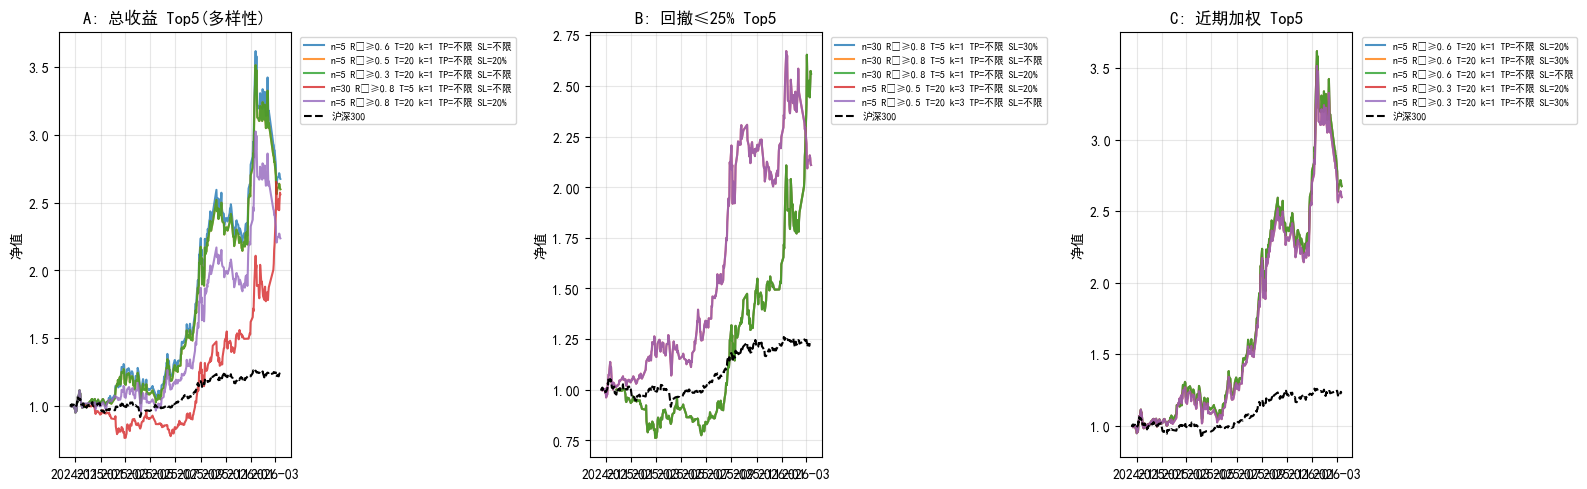

In [25]:
# 回测共同日期（取任意一条净值的索引）
common_idx = next(iter(nav_cache.values())).index
# 沪深300 净值（买入持有），与回测区间对齐
csi300_code = 'SH510300'
if csi300_code in panel.columns:
    csi300_nav = (panel.loc[common_idx, csi300_code] / panel.loc[common_idx, csi300_code].iloc[0]).rename('沪深300')
else:
    csi300_nav = pd.Series(1.0, index=common_idx).rename('沪深300')

def make_label(row):
    tp_s = f"{row['take_profit']:.0%}" if pd.notna(row.get('take_profit')) and row.get('take_profit') is not None else '不限'
    sl_s = f"{row['max_dd_stop']:.0%}" if pd.notna(row.get('max_dd_stop')) and row.get('max_dd_stop') is not None else '不限'
    return f"n={int(row['n'])} R²≥{row['R2_threshold']} T={int(row['rebal_period'])} k={int(row['top_k'])} TP={tp_s} SL={sl_s}"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
years_unique = [2024, 2025, 2026]

for ax, (name, top5_df) in zip(axes, [('A: 总收益 Top5(多样性)', top5_a), ('B: 回撤≤25% Top5', top5_b), ('C: 近期加权 Top5', top5_c)]):
    for _, row in top5_df.iterrows():
        nav = find_nav(nav_cache, row, period='full', year_list=years_unique)
        if nav is not None:
            nav = nav / nav.iloc[0]
            ax.plot(nav.index, nav.values, label=make_label(row), alpha=0.8)
    ax.plot(csi300_nav.index, csi300_nav.values, 'k--', label='沪深300', linewidth=1.5)
    ax.set_title(name)
    ax.set_ylabel('净值')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 各维度参数取不同值时收益均值对比

按 n、R2_threshold、rebal_period、top_k、take_profit、max_dd_stop 分组，对总收益（或年化）取均值并绘图。

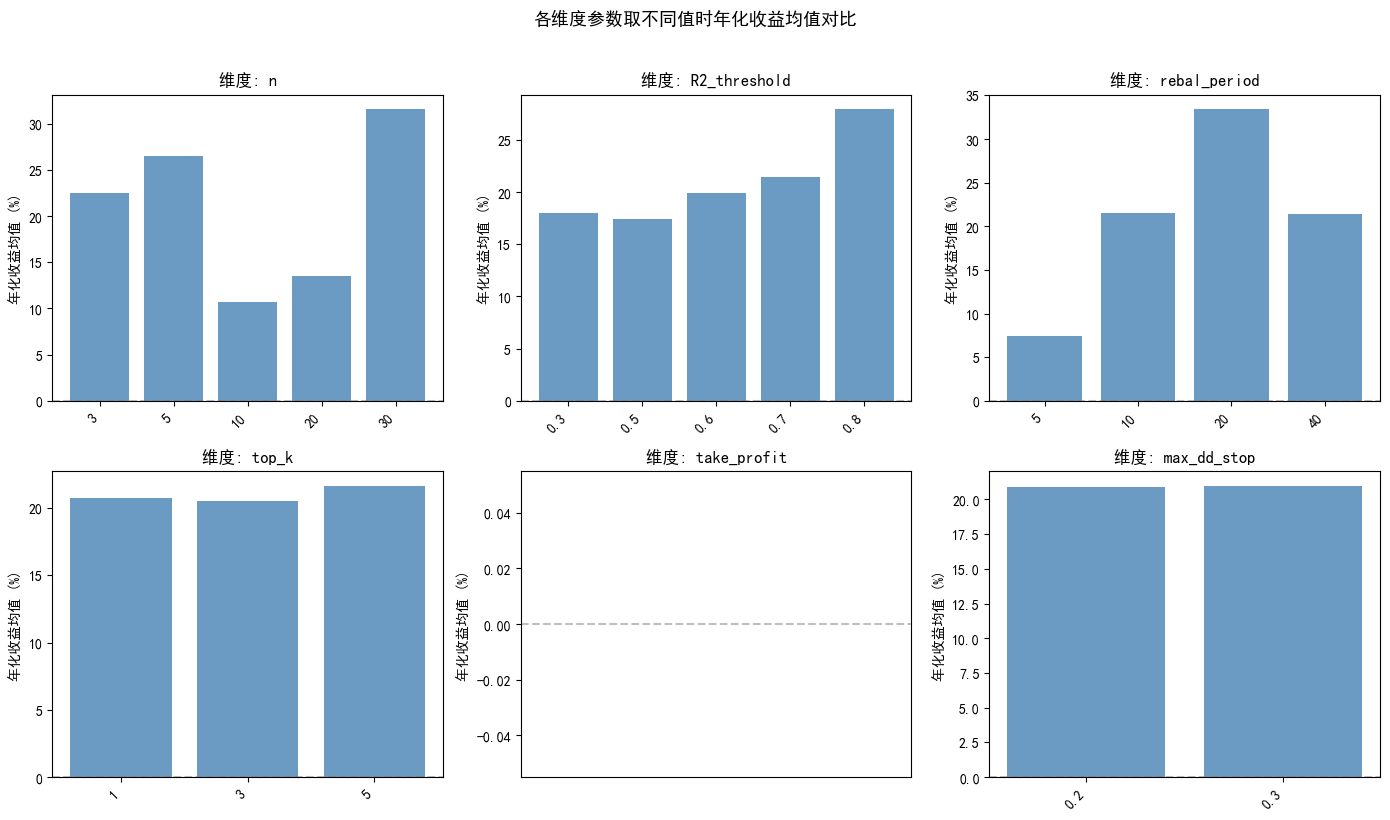

In [26]:
# 收益列用年化（更可比）
score_col = annualized_col
dim_cols = ['n', 'R2_threshold', 'rebal_period', 'top_k', 'take_profit', 'max_dd_stop']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for idx, dim in enumerate(dim_cols):
    if dim not in result_df.columns:
        continue
    by_dim = result_df.groupby(dim)[score_col].mean() * 100
    x = np.arange(len(by_dim))
    axes[idx].bar(x, by_dim.values, color='steelblue', alpha=0.8)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels([str(v) for v in by_dim.index], rotation=45, ha='right')
    axes[idx].set_ylabel('年化收益均值 (%)')
    axes[idx].set_title(f'维度: {dim}')
    axes[idx].axhline(0, color='gray', linestyle='--', alpha=0.5)
fig.suptitle('各维度参数取不同值时年化收益均值对比', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. 额外两组参数的数据与曲线

- **组1**：n=5, R²=0.6, rebal=20, top_k=1, 止盈=不限, 止损=20%
- **组2**：n=30, R²=0.8, rebal=5, top_k=1, 止盈=不限, 止损=30%

额外两组参数 · 数据


,n,R2_threshold,rebal_period,top_k,take_profit,max_dd_stop,total_ret,annualized,max_drawdown,sharpe,2024,2025,2026
270,5,0.6,20,1,不限,20%,1.675151,1.031738,-0.271097,1.864972,0.016036,1.699721,-0.057943
865,30,0.8,5,1,不限,30%,1.561244,1.070492,-0.244655,1.900530,-0.066116,0.712788,0.548979


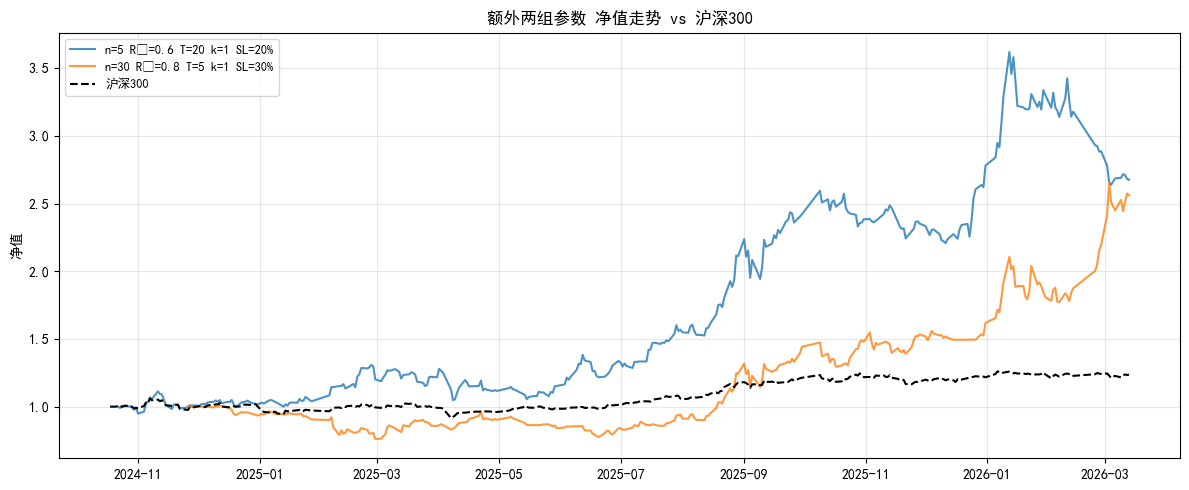

In [38]:
# 额外两组参数：(n, R2, rebal, top_k, take_profit, max_dd_stop)
extra_sets = [
    (5, 0.6, 20, 1, None, 0.2),   # 组1: 止损 20%
    (30, 0.8, 5, 1, None, 0.3),   # 组2: 止损 30%
]
extra_rows = []
for n, r2, rebal, k, tp, sl in extra_sets:
    m = (result_df['n'] == n) & (result_df['R2_threshold'] == r2) & (result_df['rebal_period'] == rebal) & (result_df['top_k'] == k)
    m = m & (result_df['take_profit'].isna() if tp is None else (result_df['take_profit'] == tp))
    if sl is None:
        m = m & result_df['max_dd_stop'].isna()
    else:
        m = m & (result_df['max_dd_stop'] == sl)
    if m.any():
        extra_rows.append(result_df.loc[m].iloc[0])
extra_df = pd.DataFrame(extra_rows) if extra_rows else pd.DataFrame()

display_cols = param_cols + [total_ret_col, annualized_col, max_dd_col, sharpe_col] + year_cols
print('额外两组参数 · 数据')
display(fmt_tp_sl(extra_df[display_cols]))

# 净值曲线：两组 + 沪深300
common_idx = next(iter(nav_cache.values())).index
csi300_code = 'SH510300'
if csi300_code in panel.columns:
    csi300_nav = (panel.loc[common_idx, csi300_code] / panel.loc[common_idx, csi300_code].iloc[0]).rename('沪深300')
else:
    csi300_nav = pd.Series(1.0, index=common_idx).rename('沪深300')

fig, ax = plt.subplots(figsize=(12, 5))
for _, row in extra_df.iterrows():
    nav = find_nav(nav_cache, row, period='full', year_list=year_cols)
    if nav is not None:
        nav = nav / nav.iloc[0]
        sl_str = f'{row["max_dd_stop"]:.0%}' if pd.notna(row['max_dd_stop']) else '不限'
        lbl = f'n={int(row["n"])} R²={row["R2_threshold"]} T={int(row["rebal_period"])} k={int(row["top_k"])} SL={sl_str}'
        ax.plot(nav.index, nav.values, label=lbl, alpha=0.8)
ax.plot(csi300_nav.index, csi300_nav.values, 'k--', label='沪深300', linewidth=1.5)
ax.set_title('额外两组参数 净值走势 vs 沪深300')
ax.set_ylabel('净值')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()